In [1]:
import pandas as pd

data = "./dataset/Housing.csv"
df = pd.read_csv(data)

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


C:\Users\Admin\AppData\Local\Temp\ipykernel_18656\1665228351.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fitting 5 folds for each of 27 candidates, totalling 135 fits

 Final Best Params: {'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.036, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 600, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.6}

 Final Evaluation on Test Data:
R² Score: 0.6792
RMSE: 0.2489
MAE: 0.1952


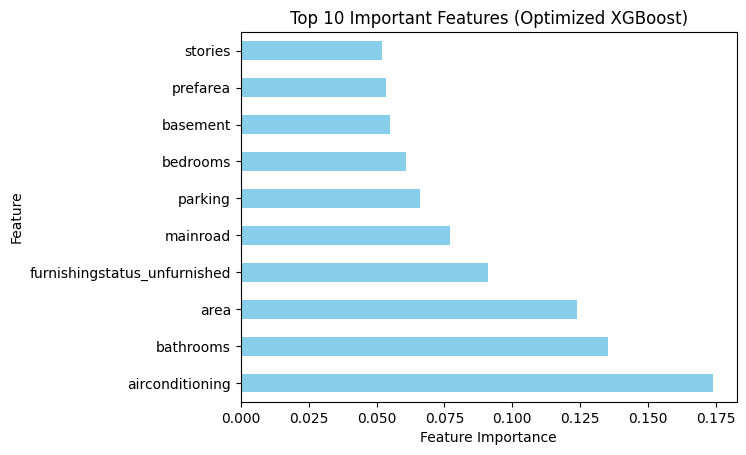

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Đọc & tiền xử lý dữ liệu 
data = "./dataset/Housing.csv"
df = pd.read_csv(data)

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Log-transform giảm skew
df['price'] = np.log1p(df['price'])
df['area'] = np.log1p(df['area'])

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomizedSearchCV để tìm vùng tốt 
xgb = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    random_state=42
)

param_dist = {
    'n_estimators': [400, 600, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [1, 1.5, 2],
    'reg_alpha': [0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=60,
    scoring='r2',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

#  GridSearch tinh chỉnh quanh kết quả tốt 
best_params = random_search.best_params_

param_grid = {
    'n_estimators': [best_params['n_estimators'] - 200, best_params['n_estimators'], best_params['n_estimators'] + 200],
    'learning_rate': [best_params['learning_rate'] * 0.8, best_params['learning_rate'], best_params['learning_rate'] * 1.2],
    'max_depth': [best_params['max_depth'] - 1, best_params['max_depth'], best_params['max_depth'] + 1],
    'subsample': [best_params['subsample']],
    'colsample_bytree': [best_params['colsample_bytree']],
    'min_child_weight': [best_params['min_child_weight']],
    'gamma': [best_params['gamma']],
    'reg_lambda': [best_params['reg_lambda']],
    'reg_alpha': [best_params['reg_alpha']]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\n Final Best Params:", grid_search.best_params_)

# Đánh giá trên tập test
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"\n Final Evaluation on Test Data:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Biểu đồ Feature Importance 
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features (Optimized XGBoost)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()